In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class SGD:
    def __init__(self, lr=1e-2):
        self.lr = lr
    def step(self, x, g):
        return x - self.lr * g

class Momentum:
    def __init__(self, lr=1e-2, beta=0.9):
        self.lr = lr
        self.beta = beta
        self.v = None
    def step(self, x, g):
        if self.v is None:
            self.v = np.zeros_like(x)
        self.v = self.beta*self.v - self.lr*g
        return x + self.v

class Adagrad:
    def __init__(self, lr=1e-1, eps=1e-8):
        self.lr = lr
        self.eps = eps
        self.G = None
    def step(self, x, g):
        if self.G is None:
            self.G = np.zeros_like(x)
        self.G += g*g
        return x - self.lr * g / (np.sqrt(self.G) + self.eps)

class RMSprop:
    def __init__(self, lr=1e-2, beta=0.9, eps=1e-8):
        self.lr = lr
        self.beta = beta
        self.eps = eps
        self.Eg2 = None
    def step(self, x, g):
        if self.Eg2 is None:
            self.Eg2 = np.zeros_like(x)
        self.Eg2 = self.beta*self.Eg2 + (1-self.beta)*(g*g)
        return x - self.lr * g / (np.sqrt(self.Eg2) + self.eps)

class Adam:
    def __init__(self, lr=1e-2, b1=0.9, b2=0.999, eps=1e-8):
        self.lr = lr
        self.b1 = b1
        self.b2 = b2
        self.eps = eps
        self.m = None
        self.v = None
        self.t = 0
    def step(self, x, g):
        if self.m is None:
            self.m = np.zeros_like(x)
            self.v = np.zeros_like(x)
        self.t += 1
        self.m = self.b1*self.m + (1-self.b1)*g
        self.v = self.b2*self.v + (1-self.b2)*(g*g)
        m_hat = self.m / (1 - self.b1**self.t)
        v_hat = self.v / (1 - self.b2**self.t)
        return x - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


In [3]:
def bowl(x):  # parabolida
    return x[0]**2 + x[1]**2

def grad_bowl(x):
    return np.array([2*x[0], 2*x[1]])

def saddle(x):  # siodło
    return x[0]**2 - x[1]**2

def grad_saddle(x):
    return np.array([2*x[0], -2*x[1]])

def half_cylinder(x):  # półwalec: jedna oś płaska, druga zakrzywiona
    return x[0]**2

def grad_half_cylinder(x):
    return np.array([2*x[0], 0.0])

def slope(x):  # stok: funkcja liniowa (stały gradient)
    return 2.0*x[0] + 1.0*x[1]

def grad_slope(x):
    return np.array([2.0, 1.0])

def slope_with_shelf(x):
    # "stok z półką": stok, ale w pasie |x0|<1 gradient w x0 jest prawie 0
    # (gładka aproksymacja przez tanh)
    return 2.0*np.tanh(2.0*x[0]) + 1.0*x[1]

def grad_slope_with_shelf(x):
    # d/dx tanh(ax) = a*(1 - tanh(ax)^2)
    return np.array([2.0 * 2.0 * (1.0 - np.tanh(2.0*x[0])**2), 1.0])

In [4]:
def run_optimizer(f, grad_f, opt, x0=np.array([3.0, 3.0]), steps=100):
    x = x0.copy()
    path = [x.copy()]
    vals = [f(x)]
    for _ in range(steps):
        g = grad_f(x)
        x = opt.step(x, g)
        path.append(x.copy())
        vals.append(f(x))
    return np.stack(path), np.array(vals)

In [5]:
def plot_contour_and_paths(f, paths, title, xlim=(-4,4), ylim=(-4,4), levels=30):
    xs = np.linspace(xlim[0], xlim[1], 200)
    ys = np.linspace(ylim[0], ylim[1], 200)
    X, Y = np.meshgrid(xs, ys)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i,j] = f(np.array([X[i,j], Y[i,j]]))

    plt.figure(figsize=(7,6))
    plt.contour(X, Y, Z, levels=levels)
    for name, p in paths.items():
        plt.plot(p[:,0], p[:,1], marker='o', markersize=2, linewidth=1, label=name)
    plt.title(title)
    plt.legend()
    plt.show()

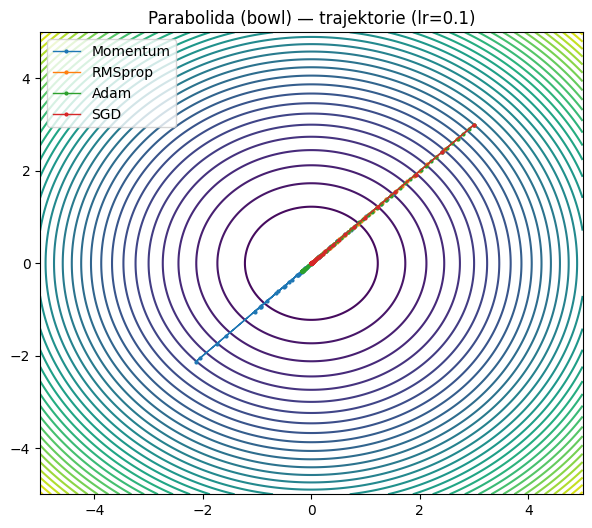

In [6]:
title = "Parabolida (bowl)"
f, grad_f = bowl, grad_bowl
x0 = np.array([3.0, 3.0])
steps = 60
lr = 0.1

opts = {
    "Momentum": Momentum(lr=lr, beta=0.9),
    "RMSprop": RMSprop(lr=lr, beta=0.9),
    "Adam": Adam(lr=lr),
    "SGD": SGD(lr=lr),
}

paths = {name: run_optimizer(f, grad_f, opt, x0=x0, steps=steps)[0] for name, opt in opts.items()}

plot_contour_and_paths(f, paths, f"{title} — trajektorie (lr={lr})", xlim=(-5,5), ylim=(-5,5), levels=35)

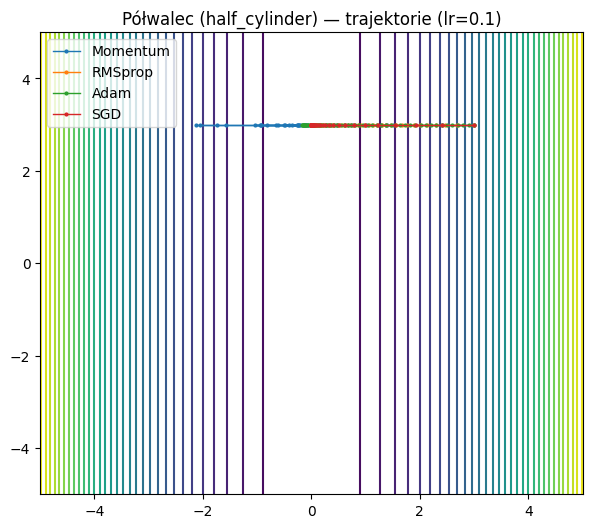

In [7]:
title = "Półwalec (half_cylinder)"
f, grad_f = half_cylinder, grad_half_cylinder
x0 = np.array([3.0, 3.0])
steps = 50
lr = 0.1

opts = {
    "Momentum": Momentum(lr=lr, beta=0.9),
    "RMSprop": RMSprop(lr=lr, beta=0.9),
    "Adam": Adam(lr=lr),
    "SGD": SGD(lr=lr),
}

paths = {name: run_optimizer(f, grad_f, opt, x0=x0, steps=steps)[0] for name, opt in opts.items()}

plot_contour_and_paths(f, paths, f"{title} — trajektorie (lr={lr})", xlim=(-5,5), ylim=(-5,5), levels=35)

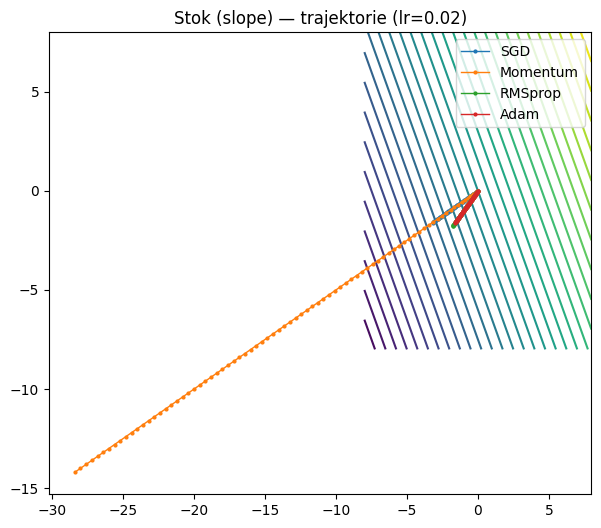

In [8]:
title = "Stok (slope)"
f, grad_f = slope, grad_slope
x0 = np.array([0.0, 0.0])
steps = 80
lr = 0.02  # mniejsze niż 0.1, bo inaczej od razu wylatuje poza zakres

opts = {
    "SGD": SGD(lr=lr),
    "Momentum": Momentum(lr=lr, beta=0.9),
    "RMSprop": RMSprop(lr=lr, beta=0.9),
    "Adam": Adam(lr=lr),
}

paths = {name: run_optimizer(f, grad_f, opt, x0=x0, steps=steps)[0] for name, opt in opts.items()}

plot_contour_and_paths(f, paths, f"{title} — trajektorie (lr={lr})", xlim=(-8,8), ylim=(-8,8), levels=35)

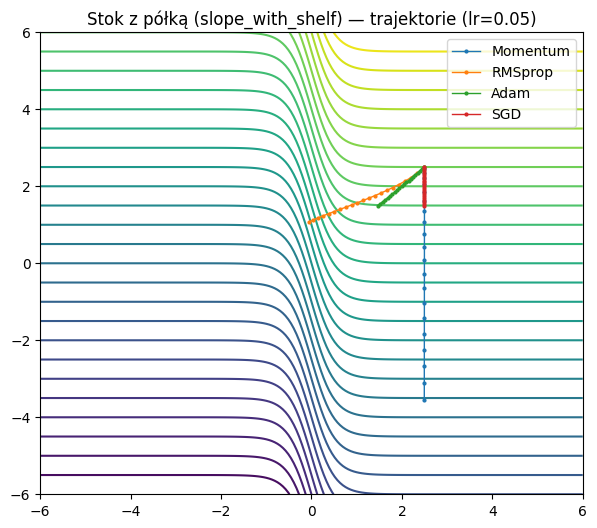

In [9]:
title = "Stok z półką (slope_with_shelf)"
f, grad_f = slope_with_shelf, grad_slope_with_shelf
x0 = np.array([2.5, 2.5])
steps = 20
lr = 0.05

opts = {
    "Momentum": Momentum(lr=lr, beta=0.9),
    "RMSprop": RMSprop(lr=lr, beta=0.9),
    "Adam": Adam(lr=lr),
    "SGD": SGD(lr=lr),
}

paths = {name: run_optimizer(f, grad_f, opt, x0=x0, steps=steps)[0] for name, opt in opts.items()}

plot_contour_and_paths(f, paths, f"{title} — trajektorie (lr={lr})", xlim=(-6,6), ylim=(-6,6), levels=35)

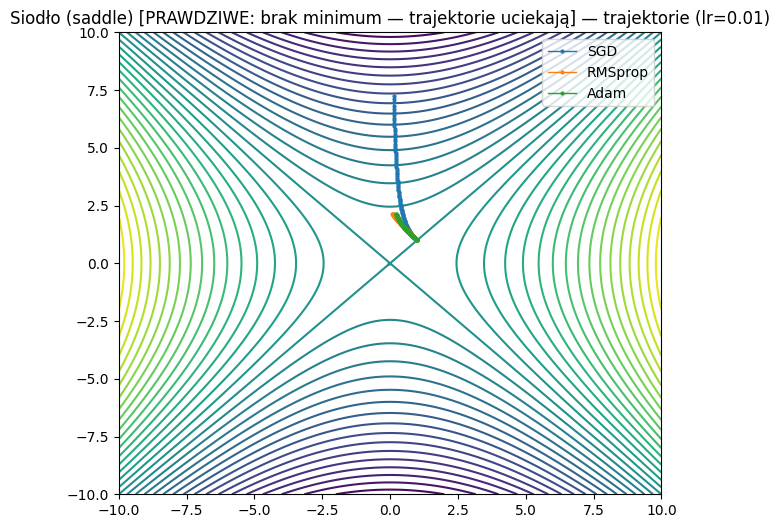

In [10]:
title = "Siodło (saddle) [PRAWDZIWE: brak minimum — trajektorie uciekają]"
f, grad_f = saddle, grad_saddle

x0 = np.array([1.0, 1.0])

steps = 100
lr = 0.01

opts = {
    "SGD": SGD(lr=lr),
    # "Momentum": Momentum(lr=lr, beta=0.9),
    "RMSprop": RMSprop(lr=lr, beta=0.9),
    "Adam": Adam(lr=lr),
}

paths = {name: run_optimizer(f, grad_f, opt, x0=x0, steps=steps)[0] for name, opt in opts.items()}

plot_contour_and_paths(f, paths, f"{title} — trajektorie (lr={lr})", xlim=(-10,10), ylim=(-10,10), levels=35)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

def make_grid(f, xlim=(-4, 4), ylim=(-4, 4), n=200):
    xs = np.linspace(xlim[0], xlim[1], n)
    ys = np.linspace(ylim[0], ylim[1], n)
    X, Y = np.meshgrid(xs, ys)
    Z = np.zeros_like(X, dtype=float)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))
    return X, Y, Z

def plot_surface_and_contours_with_paths(
    f,
    paths,
    title,
    xlim=(-4,4),
    ylim=(-4,4),
    levels=30,
    grid_n=200,
    elev=45,
    azim=-60
):
    X, Y, Z = make_grid(f, xlim=xlim, ylim=ylim, n=grid_n)

    fig = plt.figure(figsize=(14, 6))

    # ---- Left: 2D contour + paths ----
    ax1 = fig.add_subplot(1, 2, 1)
    cs = ax1.contour(X, Y, Z, levels=levels)
    ax1.clabel(cs, inline=1, fontsize=8)

    for name, p in paths.items():
        ax1.plot(p[:, 0], p[:, 1], marker="o", markersize=2, linewidth=1, label=name)

    ax1.set_title(title + " (2D contour)")
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.legend()

    # ---- Right: 3D surface + paths ----
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.plot_surface(X, Y, Z, cmap="viridis", alpha=0.75, linewidth=0, antialiased=True)

    for name, p in paths.items():
        z_path = np.array([f(pt) for pt in p])
        ax2.plot(p[:, 0], p[:, 1], z_path, marker="o", markersize=2, linewidth=1, label=name)

    ax2.set_title(title + " (3D surface)")
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_zlabel("f(x,y)")
    ax2.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    plt.show()

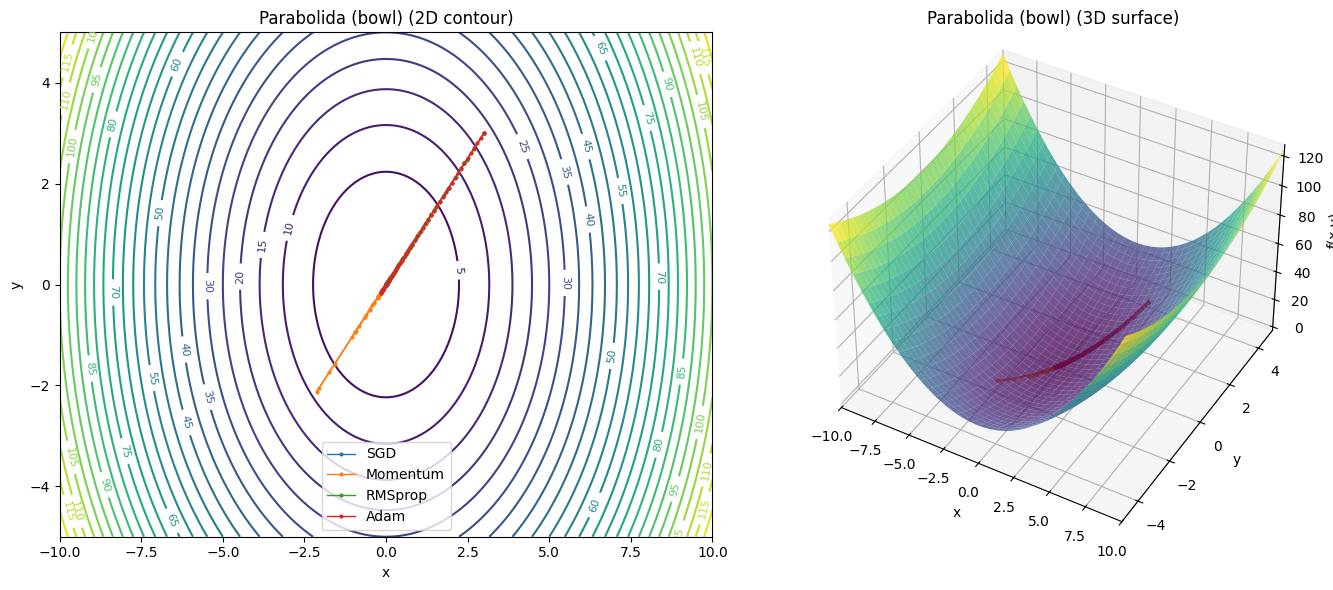

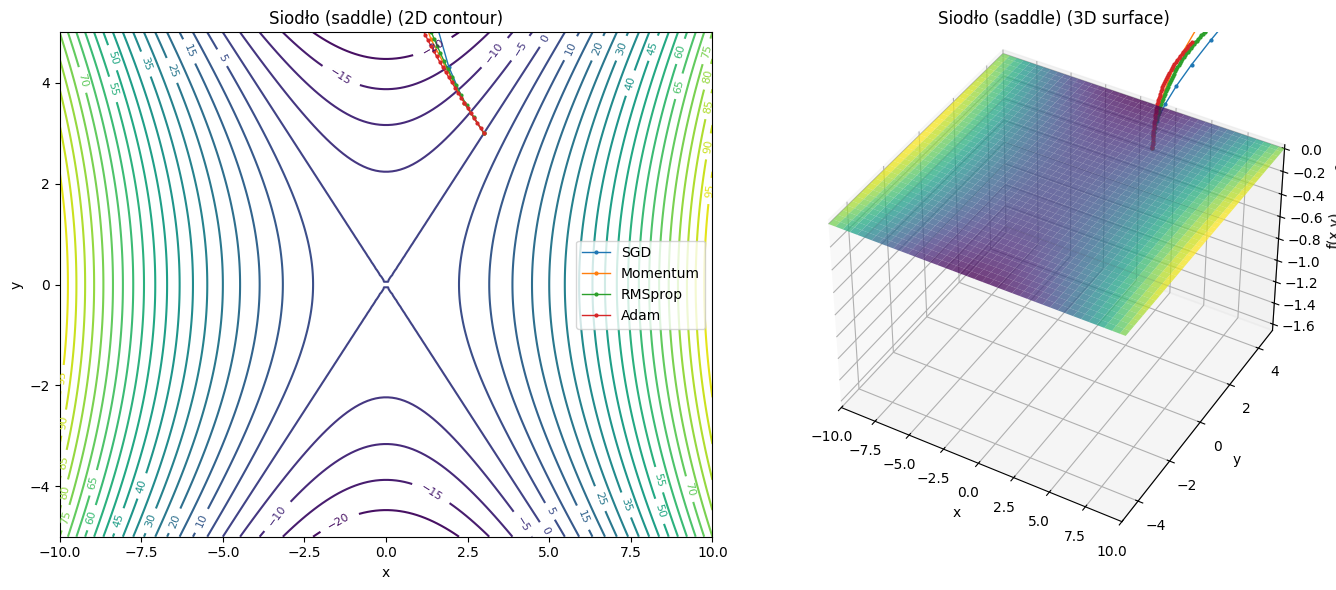

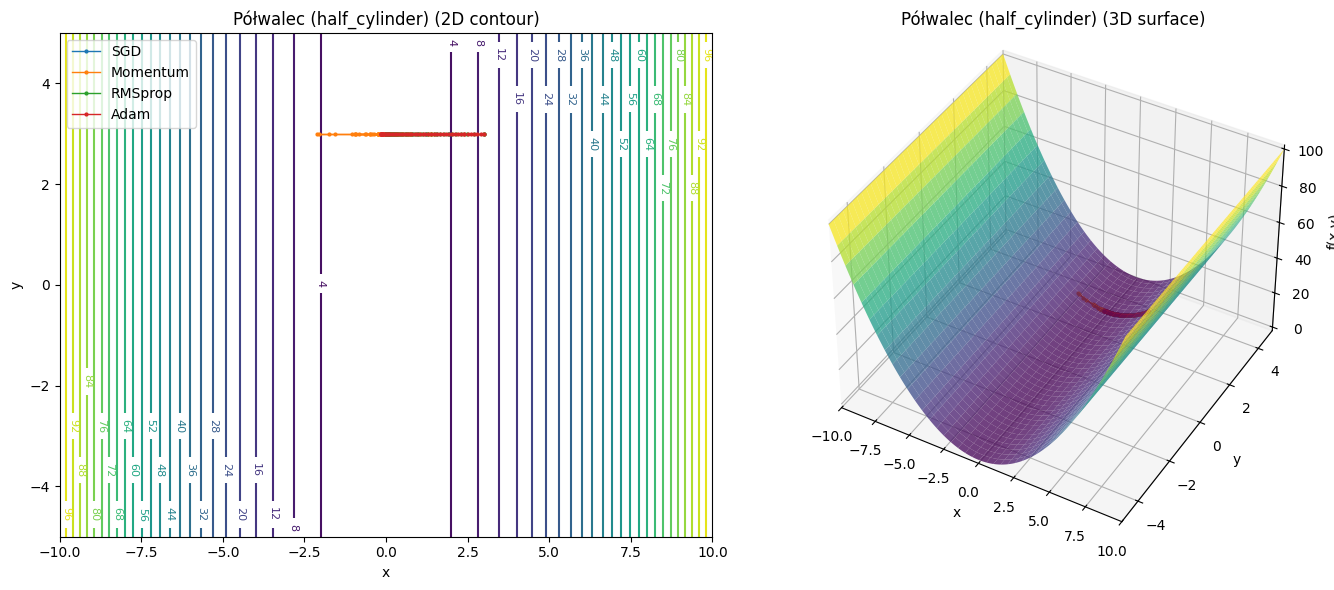

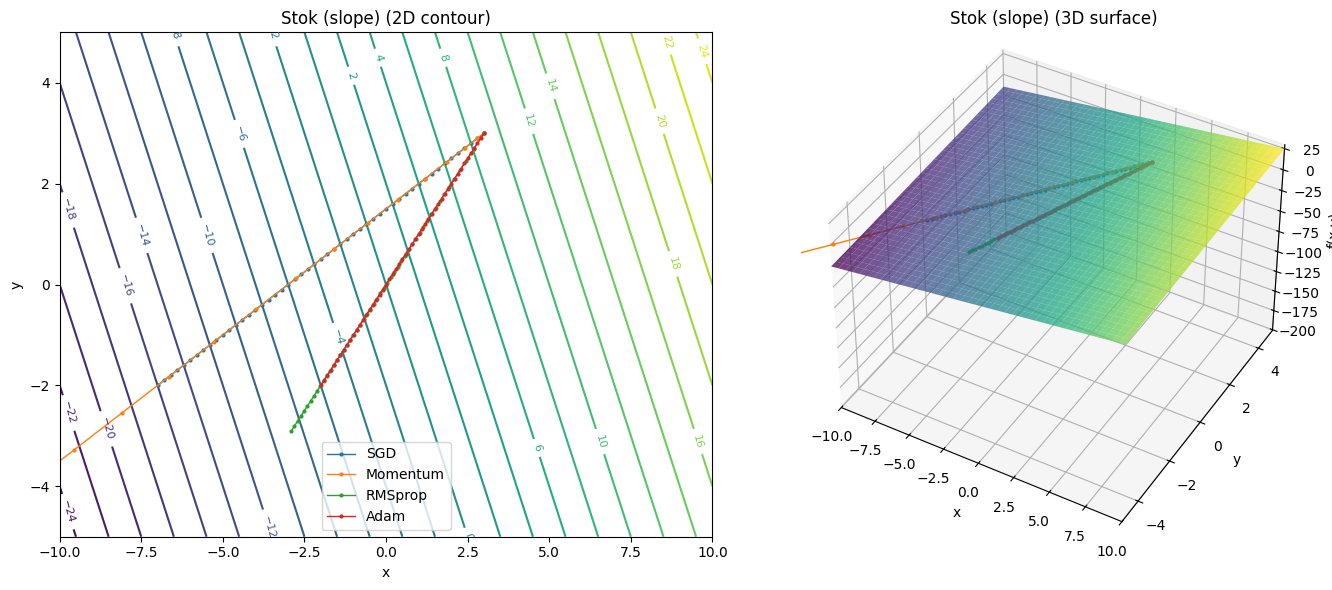

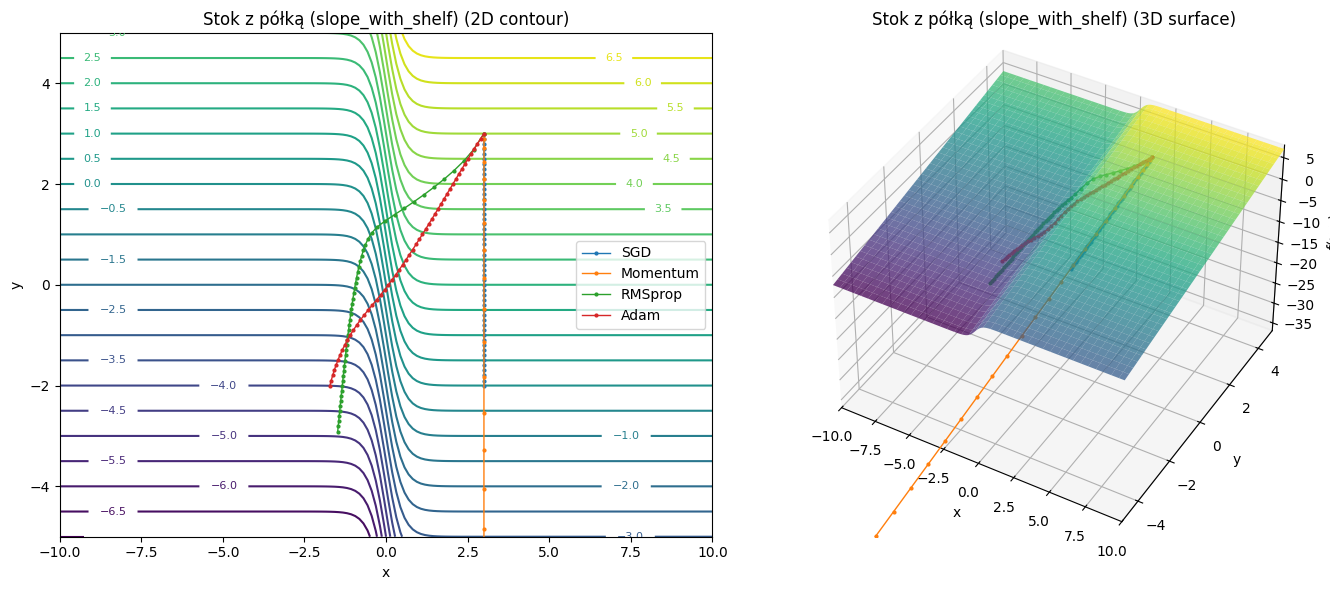

In [13]:
surfaces = [
    ("Parabolida (bowl)", bowl, grad_bowl),
    ("Siodło (saddle)", saddle, grad_saddle),
    ("Półwalec (half_cylinder)", half_cylinder, grad_half_cylinder),
    ("Stok (slope)", slope, grad_slope),
    ("Stok z półką (slope_with_shelf)", slope_with_shelf, grad_slope_with_shelf),
]

x0 = np.array([3.0, 3.0])
steps = 50

for title, f, grad_f in surfaces:
    opts = {
        "SGD": SGD(lr=0.1),
        "Momentum": Momentum(lr=0.1, beta=0.9),
        "RMSprop": RMSprop(lr=0.1, beta=0.9),
        "Adam": Adam(lr=0.1),
    }
    paths = {}
    for name, opt in opts.items():
        p, _ = run_optimizer(f, grad_f, opt, x0=x0, steps=steps)
        paths[name] = p

    plot_surface_and_contours_with_paths(
        f,
        paths,
        title=title,
        xlim=(-10, 10),
        ylim=(-5, 5),
        levels=30,
        grid_n=160,
        elev=40,
        azim=-60
    )